# **Installing Required Libraries**

In [1]:
!pip install tensorflow

In [2]:
!pip install torch

In [3]:
import numpy as np
import pandas as pd

#**Data Loading and Preprocessing**


* Loading accelerometer and orientation data from the new CSV files
and assigns a class label to each dataset.
* The data is then resampled at 10ms intervals and missing values are handled.










In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
filename = ('/content/drive/MyDrive/CPSC_5616EL_Assignment4/JJ/Accelerometer.csv')
df_newJJAcc = pd.read_csv(filename)
filename = ('/content/drive/MyDrive/CPSC_5616EL_Assignment4/Lu/Accelerometer.csv')
df_newLuAcc = pd.read_csv(filename)
filename = ('/content/drive/MyDrive/CPSC_5616EL_Assignment4/Sq/Accelerometer.csv')
df_newSqAcc = pd.read_csv(filename)
filename = ('/content/drive/MyDrive/CPSC_5616EL_Assignment4/JJ/Orientation.csv')
df_newJJOr = pd.read_csv(filename)
filename = ('/content/drive/MyDrive/CPSC_5616EL_Assignment4/Lu/Orientation.csv')
df_newLuOr = pd.read_csv(filename)
filename = ('/content/drive/MyDrive/CPSC_5616EL_Assignment4/Sq/Orientation.csv')
df_newSqOr = pd.read_csv(filename)

In [6]:
df_newJJAcc["Class"] = 0
df_newJJOr["Class"] = 0
df_newLuAcc["Class"] = 1
df_newLuOr["Class"] = 1
df_newSqAcc["Class"] = 2
df_newSqOr["Class"] = 2

In [7]:
df_newJJAcc.head(1), df_newJJOr.head(1), df_newLuAcc.head(1), df_newLuOr.head(1), df_newSqAcc.head(1), df_newSqOr.head(1)

(                  time  seconds_elapsed    z    y    x  Class
 0  1700421870111419100         0.094419  0.0  0.0  0.0      0,
                   time  seconds_elapsed        qz        qy        qx  \
 0  1700421870078178600         0.061178  0.564977  0.061691  0.104249   
 
          qw      roll    pitch       yaw  Class  
 0  0.816166 -0.017613 -0.24224 -1.213133      0  ,
                   time  seconds_elapsed         z         y         x  Class
 0  1700422426379004400         0.118004 -0.589644 -0.116638 -0.495281      1,
                   time  seconds_elapsed        qz        qy        qx  \
 0  1700422426341365800         0.080366  0.622537  0.036817  0.026298   
 
          qw      roll     pitch       yaw  Class  
 0  0.781281  0.024883 -0.087043 -1.344509      1  ,
                   time  seconds_elapsed    z    y    x  Class
 0  1700421989186816500         0.088816  0.0  0.0  0.0      2,
                   time  seconds_elapsed       qz        qy        qx  \
 0  1700

In [8]:
df_newAcc = pd.concat([df_newJJAcc, df_newLuAcc, df_newSqAcc], ignore_index=True, sort=False)

In [9]:
df_newOr = pd.concat([df_newJJOr, df_newLuOr, df_newSqOr], ignore_index=True, sort=False)

In [10]:
df_newAcc, df_newOr

(                     time  seconds_elapsed         z         y         x  \
 0     1700421870111419100         0.094419  0.000000  0.000000  0.000000   
 1     1700421870130386000         0.113386  0.108608  0.092417 -0.182402   
 2     1700421870149352400         0.132353 -0.317981  0.324736 -0.302392   
 3     1700421870168319200         0.151319 -1.008744  0.224480 -0.444053   
 4     1700421870187286000         0.170286 -0.935632  0.275390 -0.398248   
 ...                   ...              ...       ...       ...       ...   
 6782  1700422030005131800        40.907132  4.145944 -1.011379 -0.810892   
 6783  1700422030024099600        40.926100  1.649941  0.622580  1.141571   
 6784  1700422030043067400        40.945067 -0.168256  0.304213  0.065402   
 6785  1700422030062035000        40.964035 -2.171528  0.575909 -0.316782   
 6786  1700422030081002800        40.983003 -2.301008  0.080147 -1.152588   
 
       Class  
 0         0  
 1         0  
 2         0  
 3         0  

## **Converting the time to readable format in nanoseconds and making it Index**

In [11]:
df_newAcc.index = pd.to_datetime(df_newAcc["time"], unit="ns")
df_newAcc.head(1)

,time,seconds_elapsed,z,y,x,Class
time,,,,,,
2023-11-19 19:24:30.111419100,1700421870111419100,0.094419,0.0,0.0,0.0,0


In [12]:
df_newOr.index = pd.to_datetime(df_newOr["time"], unit="ns")
df_newOr.head(1)

,time,seconds_elapsed,qz,qy,qx,qw,roll,pitch,yaw,Class
time,,,,,,,,,,
2023-11-19 19:24:30.078178600,1700421870078178600,0.061178,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.24224,-1.213133,0


In [13]:
# Removing the "time" and "seconds_elapsed" columns from the accelerometer & orientation DataFrame
df_newAcc.drop(["time", "seconds_elapsed"], axis=1, inplace=True)
df_newOr.drop(["time", "seconds_elapsed"], axis=1, inplace=True)

In [14]:
df_new = pd.concat([df_newAcc.iloc[:, :3], df_newOr], axis=1)
df_new

,z,y,x,qz,qy,qx,qw,roll,pitch,yaw,Class
time,,,,,,,,,,,
2023-11-19 19:24:30.078178600,NaN,NaN,NaN,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0.0
2023-11-19 19:24:30.094847200,NaN,NaN,NaN,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0.0
2023-11-19 19:24:30.111419100,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-19 19:24:30.111519200,NaN,NaN,NaN,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0.0
2023-11-19 19:24:30.128182000,NaN,NaN,NaN,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2023-11-19 19:34:41.972256300,NaN,NaN,NaN,0.498223,0.134749,0.171762,0.839115,0.060707,-0.436231,-1.058159,1.0
2023-11-19 19:34:41.976232400,-0.302071,-1.123161,-0.658187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-19 19:34:41.988929500,NaN,NaN,NaN,0.498223,0.134749,0.171762,0.839115,0.060707,-0.436231,-1.058159,1.0


In [15]:
df_new.columns = ['acc_z', 'acc_y', 'acc_x', 'or_qz', 'or_qy', 'or_qx', 'or_qw', 'or_roll', 'or_pitch', 'or_yaw', 'Class']
df_new.head(1)

,acc_z,acc_y,acc_x,or_qz,or_qy,or_qx,or_qw,or_roll,or_pitch,or_yaw,Class
time,,,,,,,,,,,
2023-11-19 19:24:30.078178600,NaN,NaN,NaN,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.24224,-1.213133,0.0


## **Resampling the data at 10ms intervals**

In [16]:
sampling = {
    "acc_z": "mean",
    "acc_y": "mean",
    "acc_x": "mean",
    "or_qz": "mean",
    "or_qy": "mean",
    "or_qx": "mean",
    "or_qw": "mean",
    "or_roll": "mean",
    "or_pitch": "mean",
    "or_yaw": "mean",
    "Class": "last",
}

In [17]:
df_new_resampled = df_new.resample(rule="10ms").apply(sampling).dropna()
df_new_resampled["Class"] = df_new_resampled["Class"].astype("int")
df_new_resampled

,acc_z,acc_y,acc_x,or_qz,or_qy,or_qx,or_qw,or_roll,or_pitch,or_yaw,Class
time,,,,,,,,,,,
2023-11-19 19:24:30.110,0.000000,0.000000,0.000000,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.140,-0.317981,0.324736,-0.302392,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.160,-1.008744,0.224480,-0.444053,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.220,-0.202098,0.113257,-0.001990,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.240,0.102385,-0.019434,-0.070201,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
...,...,...,...,...,...,...,...,...,...,...,...
2023-11-19 19:34:41.880,0.433201,-1.029939,-0.067037,0.497370,0.124919,0.155387,0.844318,0.061165,-0.397000,-1.052395,1
2023-11-19 19:34:41.900,3.337412,-0.848295,0.543483,0.497280,0.128332,0.162823,0.842456,0.059326,-0.413674,-1.054023,1
2023-11-19 19:34:41.930,-0.905374,-0.696176,-3.086843,0.497767,0.129696,0.169568,0.840627,0.054127,-0.427067,-1.057497,1


# **Loading the Data Cleaned in Assignment 3 (Part 1)**
I am going to use the Data which I already cleaned and used in Assignment 3 to increase the number of samples

In [18]:
filename = ('/content/drive/MyDrive/CPSC_5616EL_Assignment3/df_Assignment3_cleaned.csv')
df_old_resampled = pd.read_csv(filename)
df_old_resampled.set_index('time', inplace=True)
df_old_resampled

,acc_z,acc_y,acc_x,or_qz,or_qy,or_qx,or_qw,or_roll,or_pitch,or_yaw,Class
time,,,,,,,,,,,
2023-10-21 17:02:53.260,-0.743634,0.868221,0.998940,0.597364,0.025261,0.073859,0.798162,-0.048469,-0.148630,-1.288594,0
2023-10-21 17:02:53.280,3.321456,-0.839880,-0.914122,0.597364,0.025261,0.073859,0.798162,-0.048469,-0.148630,-1.288594,0
2023-10-21 17:02:53.300,2.563608,-3.274380,-0.692336,0.542820,0.052858,0.097613,0.832480,-0.018418,-0.221719,-1.157683,0
2023-10-21 17:02:53.360,-3.609509,-4.250426,-1.263302,0.526736,0.032452,0.115528,0.841516,-0.068968,-0.230665,-1.126538,0
2023-10-21 17:02:53.410,-3.212824,-4.511413,-0.290263,0.514982,0.088211,0.047191,0.851344,0.103296,-0.172053,-1.079120,0
...,...,...,...,...,...,...,...,...,...,...,...
2023-10-21 17:50:00.330,3.329029,-4.572471,-2.135333,0.709141,-0.220724,0.604235,0.288618,-1.397456,-0.035744,-2.398578,2
2023-10-21 17:50:00.390,-7.204032,-3.287009,1.471439,0.717974,-0.231856,0.587175,0.293226,-1.366427,-0.011418,-2.375419,2
2023-10-21 17:50:00.410,-4.684663,-4.095506,0.355588,0.718117,-0.232517,0.586687,0.293329,-1.365886,-0.010236,-2.374347,2


# **Concatenating the New Cleaned Data and Old Cleaned Data**

In [19]:
df_final = pd.concat([df_new_resampled, df_old_resampled], ignore_index=False, sort=False)
df_final

,acc_z,acc_y,acc_x,or_qz,or_qy,or_qx,or_qw,or_roll,or_pitch,or_yaw,Class
time,,,,,,,,,,,
2023-11-19 19:24:30.110000,0.000000,0.000000,0.000000,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.140000,-0.317981,0.324736,-0.302392,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.160000,-1.008744,0.224480,-0.444053,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.220000,-0.202098,0.113257,-0.001990,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.240000,0.102385,-0.019434,-0.070201,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
...,...,...,...,...,...,...,...,...,...,...,...
2023-10-21 17:50:00.330,3.329029,-4.572471,-2.135333,0.709141,-0.220724,0.604235,0.288618,-1.397456,-0.035744,-2.398578,2
2023-10-21 17:50:00.390,-7.204032,-3.287009,1.471439,0.717974,-0.231856,0.587175,0.293226,-1.366427,-0.011418,-2.375419,2
2023-10-21 17:50:00.410,-4.684663,-4.095506,0.355588,0.718117,-0.232517,0.586687,0.293329,-1.365886,-0.010236,-2.374347,2


In [20]:
index_column_duplicate = df_final.index.to_frame(index=False)

df_final.insert(0, 'Duplicate_Index', df_final.index)


<ipython-input-20-836fde852f6d>:1: FutureWarning: Inferring datetime64[ns] from data containing strings is deprecated and will be removed in a future version. To retain the old behavior explicitly pass Series(data, dtype=datetime64[ns])
  index_column_duplicate = df_final.index.to_frame(index=False)
<ipython-input-20-836fde852f6d>:3: FutureWarning: Inferring datetime64[ns] from data containing strings is deprecated and will be removed in a future version. To retain the old behavior explicitly pass Series(data, dtype=datetime64[ns])
  df_final.insert(0, 'Duplicate_Index', df_final.index)


In [21]:
df_final

,Duplicate_Index,acc_z,acc_y,acc_x,or_qz,or_qy,or_qx,or_qw,or_roll,or_pitch,or_yaw,Class
time,,,,,,,,,,,,
2023-11-19 19:24:30.110000,2023-11-19 19:24:30.110,0.000000,0.000000,0.000000,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.140000,2023-11-19 19:24:30.140,-0.317981,0.324736,-0.302392,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.160000,2023-11-19 19:24:30.160,-1.008744,0.224480,-0.444053,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.220000,2023-11-19 19:24:30.220,-0.202098,0.113257,-0.001990,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.240000,2023-11-19 19:24:30.240,0.102385,-0.019434,-0.070201,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-21 17:50:00.330,2023-10-21 17:50:00.330,3.329029,-4.572471,-2.135333,0.709141,-0.220724,0.604235,0.288618,-1.397456,-0.035744,-2.398578,2
2023-10-21 17:50:00.390,2023-10-21 17:50:00.390,-7.204032,-3.287009,1.471439,0.717974,-0.231856,0.587175,0.293226,-1.366427,-0.011418,-2.375419,2
2023-10-21 17:50:00.410,2023-10-21 17:50:00.410,-4.684663,-4.095506,0.355588,0.718117,-0.232517,0.586687,0.293329,-1.365886,-0.010236,-2.374347,2


In [22]:
df_final.index = pd.to_datetime(df_final["Duplicate_Index"], unit="ns").rename("time")
df_final.head()

,Duplicate_Index,acc_z,acc_y,acc_x,or_qz,or_qy,or_qx,or_qw,or_roll,or_pitch,or_yaw,Class
time,,,,,,,,,,,,
2023-11-19 19:24:30.110,2023-11-19 19:24:30.110,0.000000,0.000000,0.000000,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.24224,-1.213133,0
2023-11-19 19:24:30.140,2023-11-19 19:24:30.140,-0.317981,0.324736,-0.302392,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.24224,-1.213133,0
2023-11-19 19:24:30.160,2023-11-19 19:24:30.160,-1.008744,0.224480,-0.444053,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.24224,-1.213133,0
2023-11-19 19:24:30.220,2023-11-19 19:24:30.220,-0.202098,0.113257,-0.001990,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.24224,-1.213133,0
2023-11-19 19:24:30.240,2023-11-19 19:24:30.240,0.102385,-0.019434,-0.070201,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.24224,-1.213133,0


# **Final Dataset**
This is the final Dataset with 8192 rows and 11 columns which will be used for model training

In [23]:
del df_final["Duplicate_Index"]
df_final

,acc_z,acc_y,acc_x,or_qz,or_qy,or_qx,or_qw,or_roll,or_pitch,or_yaw,Class
time,,,,,,,,,,,
2023-11-19 19:24:30.110,0.000000,0.000000,0.000000,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.140,-0.317981,0.324736,-0.302392,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.160,-1.008744,0.224480,-0.444053,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.220,-0.202098,0.113257,-0.001990,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
2023-11-19 19:24:30.240,0.102385,-0.019434,-0.070201,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.242240,-1.213133,0
...,...,...,...,...,...,...,...,...,...,...,...
2023-10-21 17:50:00.330,3.329029,-4.572471,-2.135333,0.709141,-0.220724,0.604235,0.288618,-1.397456,-0.035744,-2.398578,2
2023-10-21 17:50:00.390,-7.204032,-3.287009,1.471439,0.717974,-0.231856,0.587175,0.293226,-1.366427,-0.011418,-2.375419,2
2023-10-21 17:50:00.410,-4.684663,-4.095506,0.355588,0.718117,-0.232517,0.586687,0.293329,-1.365886,-0.010236,-2.374347,2


In [24]:
df_final_cnn = df_final
df_final_cnn.head(1)

,acc_z,acc_y,acc_x,or_qz,or_qy,or_qx,or_qw,or_roll,or_pitch,or_yaw,Class
time,,,,,,,,,,,
2023-11-19 19:24:30.110,0.0,0.0,0.0,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.24224,-1.213133,0


In [25]:
df_final_gru = df_final
df_final_gru.head(1)

,acc_z,acc_y,acc_x,or_qz,or_qy,or_qx,or_qw,or_roll,or_pitch,or_yaw,Class
time,,,,,,,,,,,
2023-11-19 19:24:30.110,0.0,0.0,0.0,0.564977,0.061691,0.104249,0.816166,-0.017613,-0.24224,-1.213133,0


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

## **Correlation Matrix Plot**

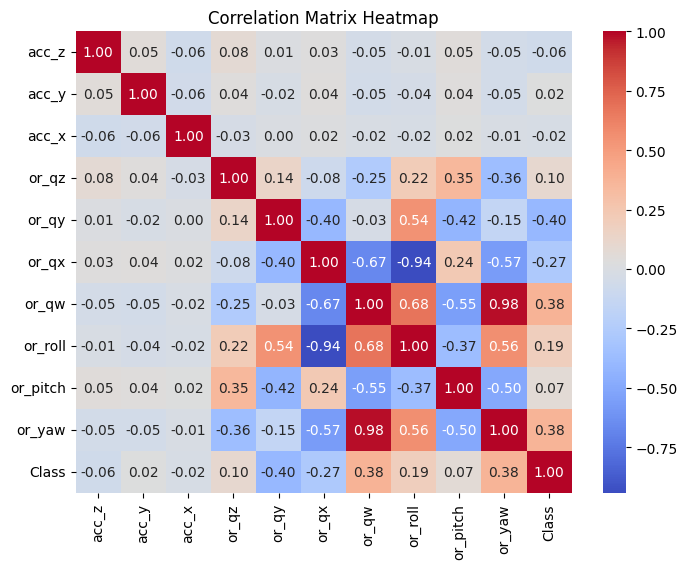

In [27]:
correlation_matrix = df_final.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

# **Outlier detection**
Outlier detection is performed using Local Outlier Factor (LOF) and visualized using boxplots.

In [28]:
from sklearn.neighbors import LocalOutlierFactor
outlier_columns = list(df_final.columns[:10])

array([<Axes: title={'center': 'or_pitch'}, xlabel='[Class]'>,
       <Axes: title={'center': 'or_qw'}, xlabel='[Class]'>,
       <Axes: title={'center': 'or_qx'}, xlabel='[Class]'>,
       <Axes: title={'center': 'or_qy'}, xlabel='[Class]'>,
       <Axes: title={'center': 'or_qz'}, xlabel='[Class]'>,
       <Axes: title={'center': 'or_roll'}, xlabel='[Class]'>,
       <Axes: title={'center': 'or_yaw'}, xlabel='[Class]'>], dtype=object)

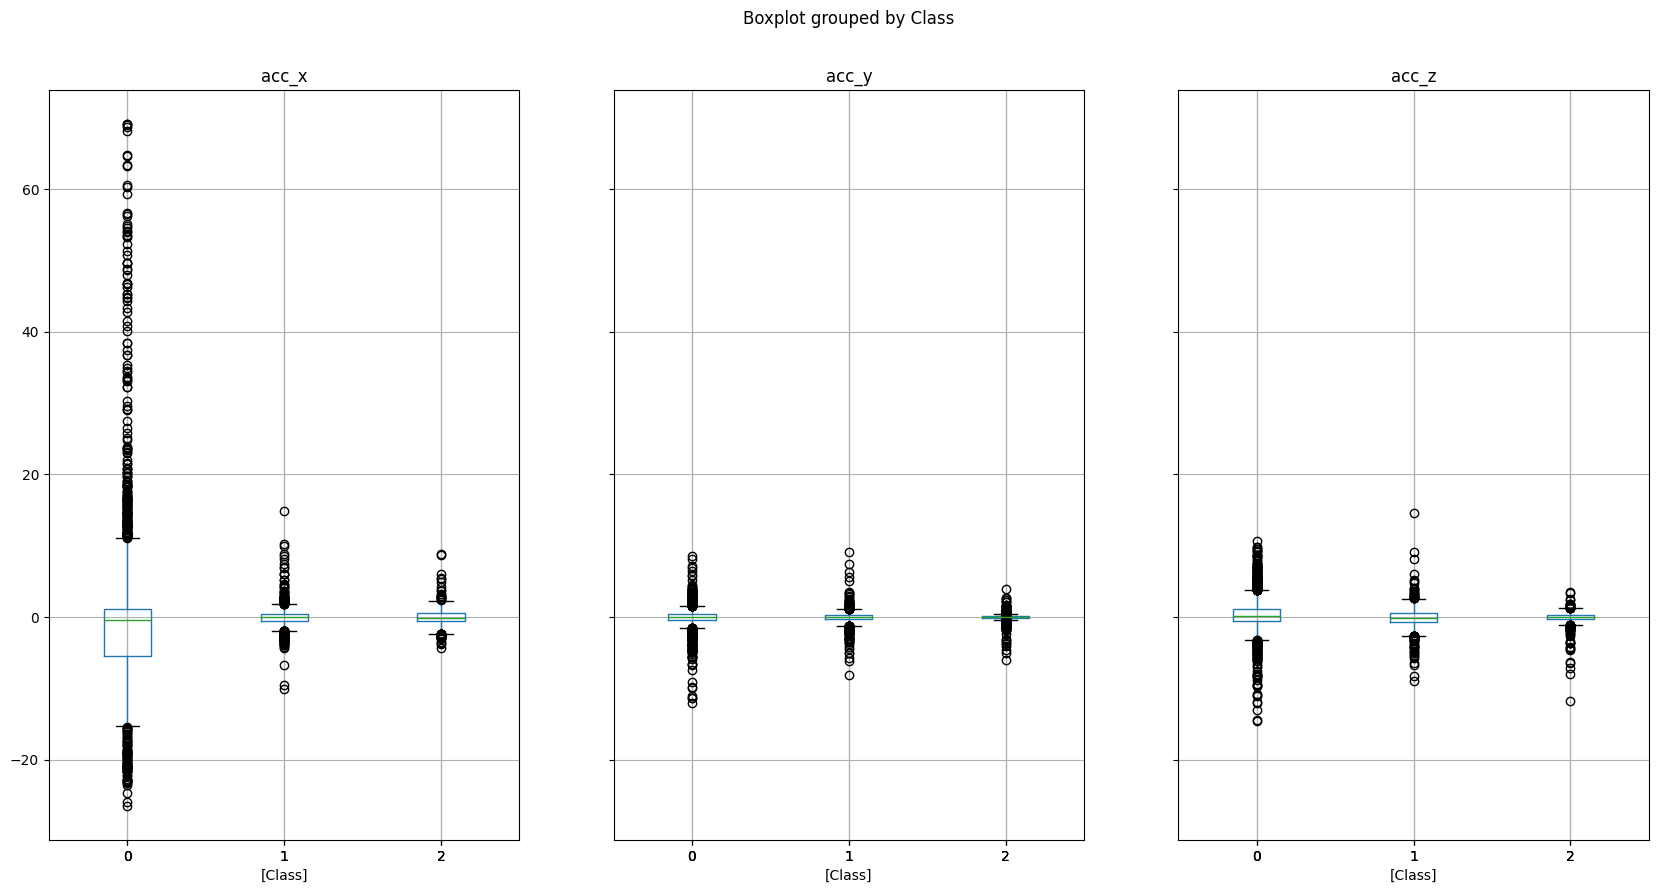

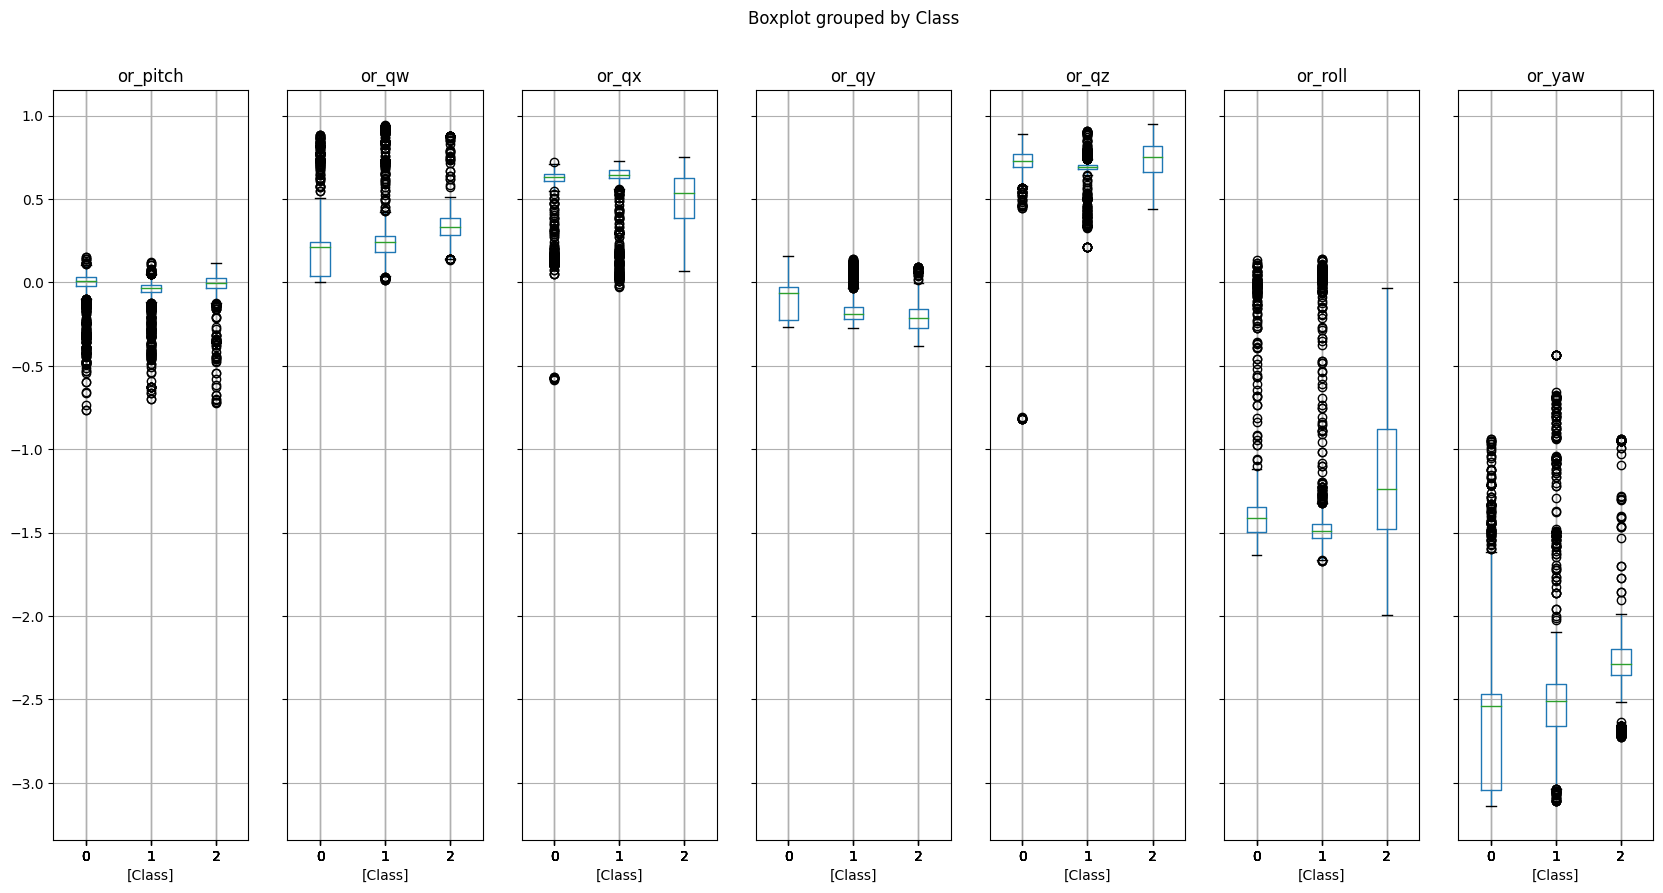

In [29]:
df_final[outlier_columns[:3] + ["Class"]].boxplot(by="Class", figsize=(20, 10), layout=(1, 3))
df_final[outlier_columns[3:] + ["Class"]].boxplot(by="Class", figsize=(20, 10), layout=(1, 7))

# **Sequence Length Analysis**
The sequence lengths of the data are analyzed and visualized using a histogram.

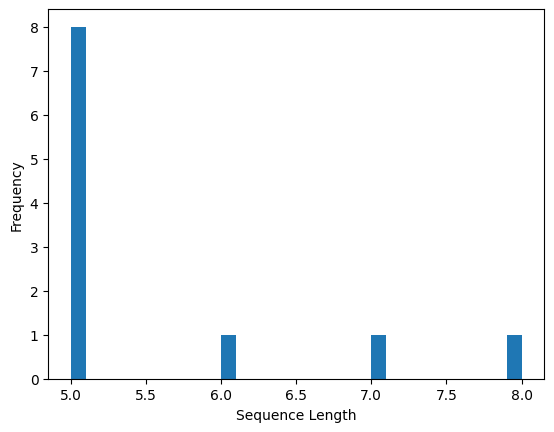

In [30]:
sequence_lengths = [len(seq) for seq in df_final_cnn]
plt.hist(sequence_lengths, bins=30)
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.show()

In [31]:
sequence_lengths = [len(seq) for seq in df_final]

print("Max sequence length:", np.max(sequence_lengths))
print("Min sequence length:", np.min(sequence_lengths))
print("Mean sequence length:", np.mean(sequence_lengths))
print("Median sequence length:", np.median(sequence_lengths))

Max sequence length: 8
Min sequence length: 5
Mean sequence length: 5.545454545454546
Median sequence length: 5.0


# **Feature Computation**

In [32]:
window_size = 100

means = []
stds = []
mins = []
maxs = []

for i in range(0, len(df_final), window_size):
    window = df_final.iloc[i:i+window_size]

    if len(window) == window_size:
        means.append(window[['acc_z', 'acc_y', 'acc_x', 'or_qz', 'or_qy', 'or_qx', 'or_qw', 'or_roll', 'or_pitch', 'or_yaw']].mean().tolist())
        stds.append(window[['acc_z', 'acc_y', 'acc_x', 'or_qz', 'or_qy', 'or_qx', 'or_qw', 'or_roll', 'or_pitch', 'or_yaw']].std().tolist())
        mins.append(window[['acc_z', 'acc_y', 'acc_x', 'or_qz', 'or_qy', 'or_qx', 'or_qw', 'or_roll', 'or_pitch', 'or_yaw']].min().tolist())
        maxs.append(window[['acc_z', 'acc_y', 'acc_x', 'or_qz', 'or_qy', 'or_qx', 'or_qw', 'or_roll', 'or_pitch', 'or_yaw']].max().tolist())

means = np.array(means)
stds = np.array(stds)
mins = np.array(mins)
maxs = np.array(maxs)

features = pd.DataFrame(np.hstack([means, stds, mins, maxs]), columns=['mean_acc_z', 'mean_acc_y', 'mean_acc_x', 'mean_or_qz', 'mean_or_qy', 'mean_or_qx', 'mean_or_qw', 'mean_or_roll', 'mean_or_pitch', 'mean_or_yaw','std_acc_z', 'std_acc_y', 'std_acc_x', 'std_or_qz', 'std_or_qy', 'std_or_qx', 'std_or_qw', 'std_or_roll', 'std_or_pitch', 'std_or_yaw','min_acc_z', 'min_acc_y', 'min_acc_x', 'min_or_qz', 'min_or_qy', 'min_or_qx', 'min_or_qw', 'min_or_roll', 'min_or_pitch', 'min_or_yaw','max_acc_z', 'max_acc_y', 'max_acc_x', 'max_or_qz', 'max_or_qy', 'max_or_qx', 'max_or_qw', 'max_or_roll', 'max_or_pitch', 'max_or_yaw',])

print(features.shape)

features.head(5)


(81, 40)


,mean_acc_z,mean_acc_y,mean_acc_x,mean_or_qz,mean_or_qy,mean_or_qx,mean_or_qw,mean_or_roll,mean_or_pitch,mean_or_yaw,...,max_acc_z,max_acc_y,max_acc_x,max_or_qz,max_or_qy,max_or_qx,max_or_qw,max_or_roll,max_or_pitch,max_or_yaw
0,-0.073809,-0.248304,-0.087492,0.680970,0.056655,0.311704,0.540619,-0.512638,-0.282869,-1.938007,...,5.615715,1.907416,6.279972,0.828018,0.128066,0.722163,0.831891,0.065591,-0.061755,-1.124246
1,0.310079,0.029249,0.412032,0.746821,-0.000896,0.659493,0.075870,-1.440653,-0.098837,-3.025809,...,9.299555,5.170467,38.418411,0.794398,0.016129,0.698446,0.113388,-1.277664,-0.062853,-2.934605
2,0.273103,0.002937,0.666389,0.772566,-0.000486,0.632256,0.048380,-1.369465,-0.060194,-3.065853,...,7.175161,3.789867,64.600449,0.802858,0.022047,0.678994,0.073104,-1.266237,-0.033819,-2.991303
3,0.637010,0.079834,1.292116,0.771167,-0.015465,0.634474,0.035910,-1.376042,-0.021626,-3.065945,...,9.192183,6.502936,56.212685,0.801177,0.010172,0.681244,0.069996,-1.276699,0.017270,-3.004527
4,0.500278,0.027559,0.203636,0.768103,-0.028821,0.638251,0.027534,-1.387013,0.009147,-3.062127,...,9.512203,6.887990,59.296455,0.811474,-0.002141,0.686668,0.053171,-1.244193,0.034291,-3.017334


# **Convolutional Neural Network (CNN)**


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


In [34]:
X = df_final_cnn.iloc[:, :10]
y = df_final_cnn.iloc[:, 10]

In [35]:
# Standardizing the features using StandardScaler
scaler = StandardScaler()

# Transforming the features (X) using the fitted StandardScaler
X = scaler.fit_transform(X)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
max_sequence_length = 8
X_train_padded = pad_sequences(X_train, maxlen=max_sequence_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test, maxlen=max_sequence_length, padding='post', truncating='post')

In [38]:
num_classes = len(set(y))
y_train_encoded = to_categorical(y_train, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

In [39]:
X_train_cnn = X_train_padded[:, :, np.newaxis]
X_test_cnn = X_test_padded[:, :, np.newaxis]

In [40]:
X_train_cnn.shape

(6553, 8, 1)

In [41]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded_onehot = tf.keras.utils.to_categorical(y_encoded)

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Flatten

model = Sequential()
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(max_sequence_length, 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(GRU(64, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_cnn, y_train_encoded, epochs=10, batch_size=32, validation_data=(X_test_cnn, y_test_encoded))

Epoch 1/10
205/205 [==============================] - 13s 17ms/step - loss: 0.7528 - accuracy: 0.7499 - val_loss: 0.6391 - val_accuracy: 0.7761
Epoch 2/10
205/205 [==============================] - 3s 13ms/step - loss: 0.5632 - accuracy: 0.7981 - val_loss: 0.5667 - val_accuracy: 0.7871
Epoch 3/10
205/205 [==============================] - 3s 13ms/step - loss: 0.5265 - accuracy: 0.8068 - val_loss: 0.5851 - val_accuracy: 0.7926
Epoch 4/10
205/205 [==============================] - 4s 18ms/step - loss: 0.5126 - accuracy: 0.8109 - val_loss: 0.5312 - val_accuracy: 0.7956
Epoch 5/10
205/205 [==============================] - 3s 15ms/step - loss: 0.5057 - accuracy: 0.8118 - val_loss: 0.5251 - val_accuracy: 0.7987
Epoch 6/10
205/205 [==============================] - 2s 10ms/step - loss: 0.5015 - accuracy: 0.8118 - val_loss: 0.5460 - val_accuracy: 0.7950
Epoch 7/10
205/205 [==============================] - 1s 6ms/step - loss: 0.4966 - accuracy: 0.8150 - val_loss: 0.5193 - val_accuracy: 0.7993

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

In [44]:
y_pred = model.predict(X_test_cnn)

52/52 [==============================] - 0s 2ms/step


In [45]:
y_test_int = np.argmax(y_test_encoded, axis=1)
y_pred_int = np.argmax(y_pred, axis=1)

## **Performance Evaluation**

In [46]:
accuracy = accuracy_score(y_test_int, y_pred_int)
precision = precision_score(y_test_int, y_pred_int, average='weighted')
recall = recall_score(y_test_int, y_pred_int, average='weighted')
f1 = f1_score(y_test_int, y_pred_int, average='weighted')
roc_auc = roc_auc_score(y_test_encoded, y_pred, average='weighted', multi_class='ovr')

In [47]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.7974
Precision: 0.8474
Recall: 0.7974
F1 Score: 0.7983
ROC AUC: 0.8925


In [48]:
conf_matrix = confusion_matrix(y_test_int, y_pred_int)
class_report = classification_report(y_test_int, y_pred_int)

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(class_report)


Confusion Matrix:
[[284 133   3]
 [ 20 617   0]
 [  7 169 406]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.68      0.78       420
           1       0.67      0.97      0.79       637
           2       0.99      0.70      0.82       582

    accuracy                           0.80      1639
   macro avg       0.86      0.78      0.80      1639
weighted avg       0.85      0.80      0.80      1639



# **Gated Recurrent Unit Networks (GRU)**

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [50]:
X = df_final_gru.iloc[:, :10]
y = df_final_gru.iloc[:, 10]

In [51]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded

array([0, 0, 0, ..., 2, 2, 2])

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
X_train.shape

(6553, 10)

In [54]:
model_gru = Sequential()
model_gru.add(GRU(128, input_shape=(X_train.shape[1], 1)))
model_gru.add(Dropout(0.5))
model_gru.add(Dense(3, activation='softmax'))

# Compile the model
model_gru.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the GRU model
history_gru = model_gru.fit(X_train, y_train_encoded, epochs=10, validation_data=(X_test, y_test_encoded), verbose=1)

# Output the summary of both models
model_gru.summary()

Epoch 1/10
205/205 [==============================] - 7s 21ms/step - loss: 0.9013 - accuracy: 0.5662 - val_loss: 0.8047 - val_accuracy: 0.6236
Epoch 2/10
205/205 [==============================] - 5s 22ms/step - loss: 0.7829 - accuracy: 0.6777 - val_loss: 0.7059 - val_accuracy: 0.7437
Epoch 3/10
205/205 [==============================] - 3s 15ms/step - loss: 0.7078 - accuracy: 0.7261 - val_loss: 0.6469 - val_accuracy: 0.7364
Epoch 4/10
205/205 [==============================] - 3s 14ms/step - loss: 0.6409 - accuracy: 0.7462 - val_loss: 0.6140 - val_accuracy: 0.7566
Epoch 5/10
205/205 [==============================] - 3s 15ms/step - loss: 0.5869 - accuracy: 0.7645 - val_loss: 0.5446 - val_accuracy: 0.7755
Epoch 6/10
205/205 [==============================] - 4s 19ms/step - loss: 0.5380 - accuracy: 0.7761 - val_loss: 0.5752 - val_accuracy: 0.7578
Epoch 7/10
205/205 [==============================] - 5s 22ms/step - loss: 0.5078 - accuracy: 0.7954 - val_loss: 0.4927 - val_accuracy: 0.8041

In [55]:
y_pred_gru = model_gru.predict(X_test)

52/52 [==============================] - 1s 6ms/step


In [56]:
y_test_int_gru = np.argmax(y_test_encoded, axis=1)
y_pred_int_gru = np.argmax(y_pred_gru, axis=1)

## **Performance Evaluation**

In [57]:
accuracy_gru = accuracy_score(y_test_int_gru, y_pred_int_gru)
precision_gru = precision_score(y_test_int_gru, y_pred_int_gru, average='weighted')
recall_gru = recall_score(y_test_int_gru, y_pred_int_gru, average='weighted')
f1_gru = f1_score(y_test_int_gru, y_pred_int_gru, average='weighted')
roc_auc_gru = roc_auc_score(y_test_encoded, y_pred_gru, average='weighted', multi_class='ovr')

In [58]:
print("Evaluation Metrics for GRU Model:")
print(f"Accuracy: {accuracy_gru:.4f}")
print(f"Precision: {precision_gru:.4f}")
print(f"Recall: {recall_gru:.4f}")
print(f"F1 Score: {f1_gru:.4f}")
print(f"ROC AUC: {roc_auc_gru:.4f}")

Evaluation Metrics for GRU Model:
Accuracy: 0.8115
Precision: 0.8276
Recall: 0.8115
F1 Score: 0.8119
ROC AUC: 0.9369


In [59]:
conf_matrix_gru = confusion_matrix(y_test_int_gru, y_pred_int_gru)
class_report_gru = classification_report(y_test_int_gru, y_pred_int_gru)

print("\nConfusion Matrix:")
print(conf_matrix_gru)

print("\nClassification Report:")
print(class_report_gru)


Confusion Matrix:
[[299 103  18]
 [ 36 577  24]
 [ 12 116 454]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.71      0.78       420
           1       0.72      0.91      0.81       637
           2       0.92      0.78      0.84       582

    accuracy                           0.81      1639
   macro avg       0.83      0.80      0.81      1639
weighted avg       0.83      0.81      0.81      1639



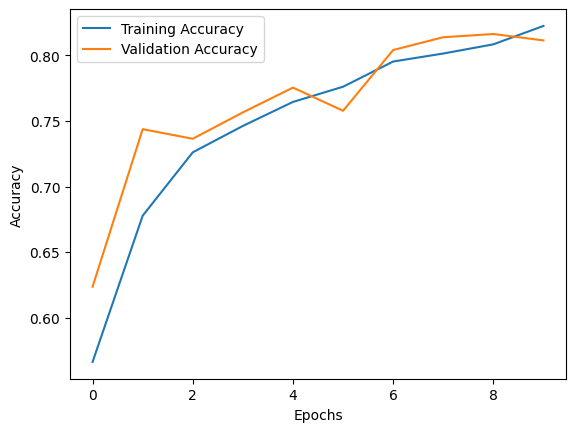

In [60]:
plt.plot(history_gru.history['accuracy'], label='Training Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# **Hybrid Model (CNN-GRU)**

In [61]:
from keras.models import Sequential
from keras.layers import Input, Conv1D, MaxPooling1D, GRU, Dense, Flatten
from keras.layers import Reshape
from keras.models import Model

In [62]:
X = df_final.iloc[:, :-1].values
y = df_final.iloc[:, -1].values

In [63]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [64]:
le = LabelEncoder()
y = le.fit_transform(y)

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [67]:
# Build the model
model = Sequential()

# 1D Convolutional layers
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))

# GRU layer
model.add(GRU(50, activation='relu'))

# Output layer
model.add(Dense(3, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_data=(X_test_cnn, y_test))

Epoch 1/10
205/205 [==============================] - 4s 7ms/step - loss: 0.6127 - accuracy: 0.7746 - val_loss: 0.3601 - val_accuracy: 0.8578
Epoch 2/10
205/205 [==============================] - 1s 5ms/step - loss: 0.3181 - accuracy: 0.8886 - val_loss: 0.2602 - val_accuracy: 0.9103
Epoch 3/10
205/205 [==============================] - 1s 5ms/step - loss: 0.2454 - accuracy: 0.9115 - val_loss: 0.2177 - val_accuracy: 0.9140
Epoch 4/10
205/205 [==============================] - 1s 6ms/step - loss: 0.2219 - accuracy: 0.9208 - val_loss: 0.2117 - val_accuracy: 0.9274
Epoch 5/10
205/205 [==============================] - 1s 5ms/step - loss: 0.1982 - accuracy: 0.9298 - val_loss: 0.2107 - val_accuracy: 0.9225
Epoch 6/10
205/205 [==============================] - 1s 6ms/step - loss: 0.1802 - accuracy: 0.9336 - val_loss: 0.2199 - val_accuracy: 0.9207
Epoch 7/10
205/205 [==============================] - 2s 8ms/step - loss: 0.1688 - accuracy: 0.9399 - val_loss: 0.1783 - val_accuracy: 0.9390
Epoch 

In [68]:
y_pred = model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)

52/52 [==============================] - 0s 2ms/step


## **Performance Evaluation**

In [69]:
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

In [70]:
print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Evaluation Metrics:
Accuracy: 0.9359
Precision: 0.9386
Recall: 0.9359
F1 Score: 0.9363


In [71]:
conf_matrix = confusion_matrix(y_test, y_pred_classes)
class_report = classification_report(y_test, y_pred_classes)

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(class_report)


Confusion Matrix:
[[378  41   1]
 [ 24 612   1]
 [  4  34 544]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       420
           1       0.89      0.96      0.92       637
           2       1.00      0.93      0.96       582

    accuracy                           0.94      1639
   macro avg       0.94      0.93      0.93      1639
weighted avg       0.94      0.94      0.94      1639

